# Машинное обучение. ВМК МГУ

# Практическое задание 2. Knn: классификация и регрессия

## Уровень: **Исследовательский (Research)**

# О формате сдачи

🔷 При решении ноутбука используйте данный шаблон

```
✅ Можно добавлять новые ячейки любых типов
❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий
```

🔷 При оценивании задач учитывается код

```
✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно
```

🔷 При оценивании задач учитываются выводы

```
✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
✅ Сопутствующие изображения, графики, таблички - приветствуются!
❌ При отсутствии выводов задание не засчитается на полный балл
```

**Примерное время выполнения (execution
time/время выполнения, если нажать run all) всех ячеек ноутбука при
правильной реализации: 10 минут **

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, возможно, нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится

На скачивание файла и установку понадобится не более 5 минут.

**Важно!**

Устанавливать нужные версии нужно каждый раз, когда создается новый
рантайм. Например, если вы 2 часа подряд делаете это задание, то
подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в
понедельник, затем закрыли/выключили ноутбук, то при продолжении в
среду, вам нужно будет запустить рантайм заново и следовательно заново
установить библиотеки.

**Важно!**
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в соответствии с гайдом .pdf)

In [ ]:
# !!! Данный блок будет работать только в Google-Colab !!!
! gdown 10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
! pip install -r /content/requirements_2024_25_for_colab_small.txt

Downloading...
From: https://drive.google.com/uc?id=10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
To: /content/requirements_2024_25_for_colab_small.txt
100% 375/375 [00:00<00:00, 1.37MB/s]


Проверим версию библиотеки:

In [ ]:
import catboost
assert(catboost.__version__ == '1.2.7')

**Внимание!** Перед выполнение данного
задания рекомендуем сначала погрузиться в [Base] ноутбук по основам
sklearn, нормализации и кросс-валидации, так как данные техники и
понятия будут активно использоваться в данном ноутбук

Теперь можно приступать к выполнению задания! :)

# Часть 1. Нормализация признакового пространства

В данном части задания исследуем, как нормализация (скейлинг) данных влияет на разделимость данных

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
import numpy as np
import seaborn as sns
import pickle

from matplotlib import pyplot as plt


plt.rcParams["figure.figsize"] = (5,5)

Загрузим файл с данными data.pkl:

In [ ]:
!gdown 1acbP4PNmu11rkBzozvIc3bowWaQL7iFe

Downloading...
From: https://drive.google.com/uc?id=1acbP4PNmu11rkBzozvIc3bowWaQL7iFe
To: /content/data.pkl
100% 5.03k/5.03k [00:00<00:00, 13.2MB/s]


Загрузим данные в память. В переменной X X будут храниться признаковые описания объектов, в переменной y − y − метки классов

In [ ]:
with open('/content/data.pkl', 'rb') as file:
    X, y = pickle.load(file)

In [ ]:
def plot_data_points(X, labels, xlim, ylim):
    g = sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels)
    g.set(xlim=xlim, ylim=ylim)
    plt.xlabel('x_1')
    plt.ylabel('x_2')
    plt.grid()

Визуализируем наши данные

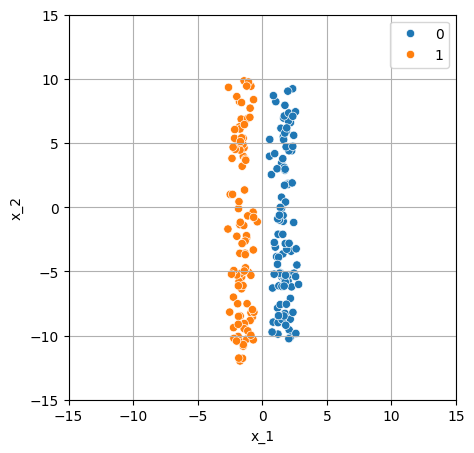

In [ ]:
plot_data_points(X, y, xlim=(-15, 15), ylim=(-15, 15))

Как видно, наши данные идеально разделяются прямой x = 0 x = 0

Функция p l o t _ k n n _ b o u n d p l o t _ k n n _ b o u n d принимает на вход объекты X X , метки классов y y , метод нормализации признаков s c a l e r s c a l e r , число соседей n _ n e i g h b o r s n _ n e i g h b o r s и границы рисунка x l i m x l i m , y l i m y l i m . Функция обучает K N N K N N классификатор с числом соседей n _ n e i g h b o r s n _ n e i g h b o r s и визуализирует разделяющую поверхность для классов, полученную с помощью обученного K N N K N N классификатора.

- Если вы не можете различить выбранные нами цвета , то измените список цветов в переменных cmap_light и cmap_bold. Актуальный список возможных цветов находится здесь

In [ ]:
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets

def plot_knn_bound(X, y, scaler=None, n_neighbors=10, xlim=(-15, 15), ylim=(-20, 20)):
    # step size in the mesh
    h = 0.05

    # Create color maps
    cmap_light = ListedColormap(['C0', 'orange', 'cyan', 'green'][:np.unique(y).shape[0]])
    cmap_bold = ['C0', 'orange', 'c', 'darkgreen'][:np.unique(y).shape[0]]

    x_min, x_max = xlim
    y_min, y_max = ylim
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    X_scaled = X # if scaler is None
    if scaler is not None:
        grid = scaler.transform(grid)
        X_scaled = scaler.transform(X)

    # we create an instance of Neighbours Classifier and fit the data.
    clf = neighbors.KNeighborsClassifier(n_neighbors, algorithm='brute')
    clf.fit(X_scaled, y)

    Z = clf.predict(grid)

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    # Plot also the training points
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y,
                    palette=cmap_bold, alpha=1.0, edgecolor="black")
    plt.xlabel('x_1')
    plt.ylabel('x_2')
    plt.title('Разделющие поверхности алгоритма {}-NN'.format(n_neighbors))
    plt.grid()
    plt.show()

Нарисуем разделющие поверхности 1 1 - N N N N и 10 10 - N N N N

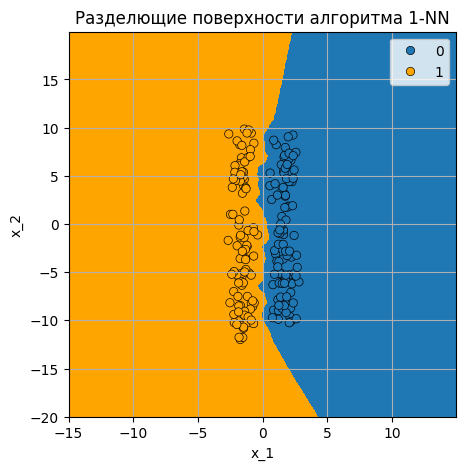

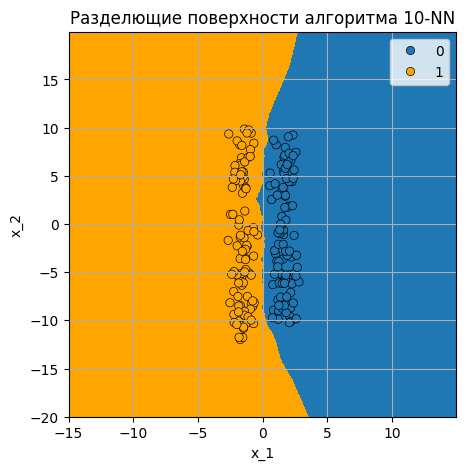

In [ ]:
plot_knn_bound(X, y, n_neighbors=1)
plot_knn_bound(X, y, n_neighbors=10)

## **Задание 1.1 (кросс-проверка, 1,5 балла)**

Объясните, почему наблюдается сильное отклоенние разделяющей поверхности от прямой x 1 = 0 x 1 = 0 при значениях x 2 < − 10 x 2 < − 10 и x 2 > 10 x 2 > 10 . Дайте **строгое математическое обоснование**
наблюдаемого явления, показывающее, что в Евклидовом пространстве
данная проблема решается нормализацией (скейлингом) признаков.

**x2 принимает значения в гораздо большем
диапазоне, нежели х1. Поэтому влиять на классификатор этот признак будет
сильнее, так как метод knn основан сугубо на вычислении Евклидового
расстояния по всем координатам и никак не учитывает различные то, что у
разных признаков разные области значений. Объекты класса 1 чуть более
растянуты по вертикали (по признаку х2), что приводит к искажению
разделяющей поверхности. После нормализации эта "растянутость"
останется, но будет иметь гораздо меньший вклад в итоговый результат.**

## **Задание 1.2 (кросс-проверка, 2 балла)**

Пусть
дано произвольное число точек на плоскости. Представим, что каждая
точка - это отдельный класс. Пусть на данной выборке был обучен 1 − N N 1 − N N классификатор. Чем с геометрической точки зрения являются разделяющие поверхности этого классификатора? Требуется **математически строго, однозначно и с полным обоснованием** определить геометрическое место точек разделяющих поверхностей.

В качестве примера ниже представлена визуализация для четырех точек

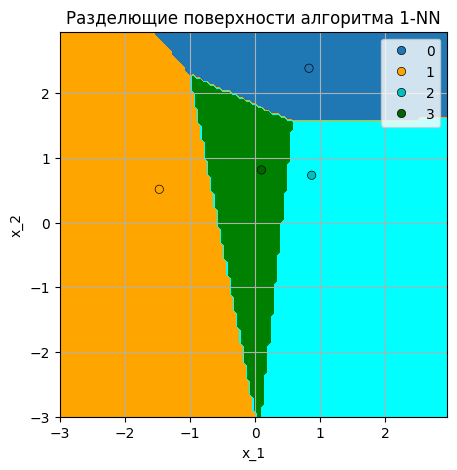

In [ ]:
X = np.random.randn(4, 2)
y = np.arange(4)
plot_knn_bound(X, y, n_neighbors=1, xlim=(-3, 3), ylim=(-3, 3))

**Диаграма Вороного (множество точек поверхности, наиболее близких к объектам класса)**

# Часть 2. Кросс-валидация

Чтобы закрепить понимание устройства кросс-валидации предлагаем вам запрограммировать данный метод самостоятельно

## **Задание 2.1 (unit-tests, 3 балла)**

В модуле cross_val.py реализуйте функции

- k f o l d _ s p l i t k f o l d _ s p l i t , которая реализует генерацию индексов обучающей и валидационной выборок для кросс-валидации
- k n n _ c v _ s c o r e k n n _ c v _ s c o r e , которая реализует кросс-валидацию для K N N − K N N − модели

Примеры запусков функций можно увидеть в открытых тестах.

# Часть 3. Работа с текстовыми данными

Далее будем решать задачу классификации новостного текста к одному из
20 классов, каждый класс соответствует определенной новостной тематике.

- В качестве метрики качества будем использовать a c c u r a c y _ s c o r e a c c u r a c y _ s c o r e .

**Accuracy** - это доля верно классифицированных объектов, среди всех объектов выборки.

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
X_train, y_train = fetch_20newsgroups(subset='train', return_X_y=True, random_state=42)
X_test, y_test = fetch_20newsgroups(subset='test', return_X_y=True, random_state=42)

In [ ]:
print(X_train[0])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----


In [ ]:
X_train = np.array(X_train, dtype=object)

In [ ]:
X_test = np.array(X_test, dtype=object)

In [ ]:
y_train = np.array(y_train)
y_test = np.array(y_test)

Как мы видим, объектами обучающей выборки являются тексты. Сырые
текстовые данные не могут служить обучающими примерами для алгоритма K N N K N N . Перед использованием K N N K N N текстовые данные переменной длины необходимо отобразить в числовой вектор фиксированной размерности.

Работа с текстовыми данными проходит в несколько этапов.

- **Токенизация.** Текстовая строка делится на токены. Как правило, в качестве токенов выступают отдельные слова и знаки препинания.
- **Нормализация.** Приведение к нижнему регистру, удаление стоп-слов, удаление пунктуации, удаление редких и частотных слов и т.д.
- **Векторизация.** Фиксируется словарь токенов V V по обучающей выборке. Текст представлется в виде вектора длиной | V | | V | , где каждый признак есть функция от частоты встречаемости токена в тексте и в обучающей выборке.

В данном задании будет использовано два вида векторизации.

- Первый, C o u n t V e c t o r i z e r C o u n t V e c t o r i z e r , сопоставляет каждому токену частоту встречаемости этого токена в тексте документа.
- Второй, T f i d f V e c t o r i z e r T f i d f V e c t o r i z e r ,
сопоставляет каждому токену частоту встречаемости этого токена в тексте
документа умноженную на величину обратно пропорциональную частоте
встречаемости токена во всех документах обучающей выборки. Подробне про t f − i d f t f − i d f предлагаем изучить самостоятельно, например, здесь .

**Полезные ссылки**

Более подробно про работу с текстами можно прочитать в статье на Хабре и в NLTK Book .

В sklearn все векторизаторы автоматически токенизируют текст и приводят его к нижнему регистру. Параметры m a x _ d f m a x _ d f и m i n _ d f m i n _ d f позволяют убрать из словаря наиболее частые и наиболее редкие токены. Параметр s t o p _ w o r d s s t o p _ w o r d s позволяет убрать из словаря стоп-слова (малоинформативные слова для данного языка, например, союзы).

In [ ]:
count_vec = CountVectorizer(max_df=0.8, min_df=10, max_features=1000, stop_words='english')
tf_idf = TfidfVectorizer(max_df=0.8, min_df=10, max_features=1000, stop_words='english')

## **Задание 3.1 (кросс-проверка, 0,5 баллa)**

Найдите оптимальные параметры обучения модели. Осуществлять перебор параметров следует по заданной ниже сетке.

- Используйте реализованные вами функции k f o l d _ s p l i t k f o l d _ s p l i t , k n n _ c v _ s c o r e k n n _ c v _ s c o r e . В качестве метрики используйте a c c u r a c y _ s c o r e a c c u r a c y _ s c o r e . 3х фолдов для кросс-валидации будет достаточно.

In [ ]:
from sklearn.metrics import accuracy_score

parameters = {
    'n_neighbors': [i for i in range(1, 11)],
    'metrics': ['cosine'],
    'weights': ['uniform', 'distance'],
    'normalizers': [(count_vec, 'CountVectorizer'), (tf_idf, 'TfidfVectorizer')]
}

Если вы все сделаете правильно, то запущенная вами кросс-валидация
будет работать примерно 7 минут. Дождитесь ее завершения, не закрывайте и
не перезагружайте этот colab ноутбук.

In [ ]:
from cross_val import kfold_split, knn_cv_score
from sklearn.neighbors import KNeighborsClassifier
folds = kfold_split(len(X_train), 3)
out = knn_cv_score(X_train, y_train, parameters, accuracy_score, folds, KNeighborsClassifier)

---------------------------------------------------------------------------
KeyError                                  Traceback (most recent call last)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py in _count_vocab(self, raw_documents, fixed_vocab)
   1277                 try:
-> 1278                     feature_idx = vocabulary[feature]
   1279                     if feature_idx not in feature_counter:

KeyError: 'conflicts'

During handling of the above exception, another exception occurred:

KeyboardInterrupt                         Traceback (most recent call last)
<ipython-input-34-6e1c0aae5c98> in <cell line: 4>()
      2 from sklearn.neighbors import KNeighborsClassifier
      3 folds = kfold_split(len(X_train), 3)
----> 4 out = knn_cv_score(X_train, y_train, parameters, accuracy_score, folds, KNeighborsClassifier)

/content/cross_val.py in knn_cv_score(X, y, parameters, score_function, folds, knn_class)
     75                         if normalizer i

In [ ]:
import statistics
count_vectorizer_values = [value for key, value in out.items() if key[0] == 'CountVectorizer']
tfid_vectorizer_values = [value for key, value in out.items() if key[0] == 'TfidfVectorizer']

cv = statistics.mean(count_vectorizer_values)
tv = statistics.mean(tfid_vectorizer_values)

result = "CountVectorizer" if cv > tv else "TfidfVectorizer"

**TfidfVectorizer. Потому что он учитывает
не только частоту встречи слова не только в данном документе, но и в
других, что делает оценку более точной и объективной**

## **Задание 3.3 (кросс-проверка, 1 балл)**

Начертите
график (line plot) зависимости метрики качества от числа соседей.
Метрику следует усреднить по всем параметрам, кроме числа соседей.
Сделайте выводы о наблюдаемых зависимостях (возможно будет полезным
ознакомиться с названиями классов)

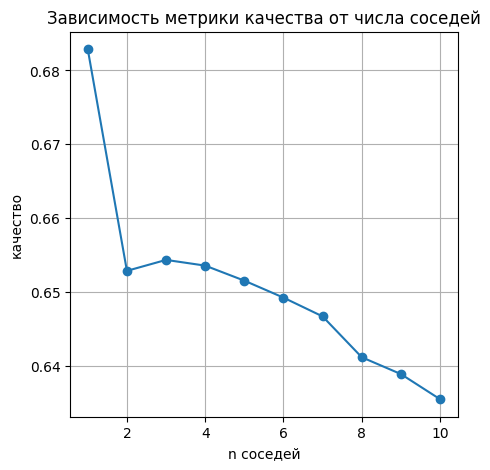

In [ ]:
neighbors_scores = {}
for key, value in out.items():
    if key[1] not in neighbors_scores:
        neighbors_scores[key[1]] = []
    neighbors_scores[key[1]].append(value)

avg_scores = {x: sum(y) / len(y) for x, y in neighbors_scores.items()}

x = list(avg_scores.keys())
y = list(avg_scores.values())

plt.grid(True)
plt.title("Зависимость метрики качества от числа соседей")
plt.xlabel("n соседей")
plt.ylabel("качество")
plt.plot(x, y, marker = 'o')

**Наилучшее качество достигается при
использовании одного соседа. Однако при увеличении числа соседей метрика
качества снижается вследствии переобучения.**

## **Задание 3.4 (кросс-проверка, 1,5 баллa)**

Оцените
точность вашей лучшей модели на тестовой части датасета. Отличается ли
оно от качества, полученного на кросс-валидации? Почему? При ответе на
поставленные вопросы вам поможет анализ распределений обучающей и
тестовой выборок

In [ ]:
max_key = max(out, key=out.get)
max_value = out[max_key]
max_value, max_key

(0.6936529067480152, ('TfidfVectorizer', 1, 'cosine', 'uniform'))


**Лучшая модель: 'TfidfVectorizer', 10, 'cosine', 'uniform', наивысшее качество 0.6277182642290952**

In [ ]:
tf_idf = TfidfVectorizer(max_df=0.8, min_df=10, max_features=1000, stop_words='english')
tf_idf.fit(X_train)
X_train_norm = tf_idf.transform(X_train)
X_test_norm = tf_idf.transform(X_test)
knn=KNeighborsClassifier(n_neighbors=1, metric='cosine',weights='uniform')
knn.fit(X_train_norm, y_train)

y_pred=knn.predict(X_test_norm)
acc = accuracy_score(y_test, y_pred)

print(acc)

0.5315985130111525


Точность на тестовой части: 0.532

Точность на кросс-валидации: 0.694

Тестовая и обучающая выборки могут иметь разное распределение
признаков. Из-за этого и вследстиве переобучения моет возникнуть
проблема, что модель, обученная на одной выборке, не так хорошо себя
показывает на другой

# **Бонус [0,5 балла]**